# **Exploring Reddit Suicidality Dataset**

In [126]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats

random_seed = 42

%matplotlib inline


In [2]:
df = pd.read_csv("suicidality_dataset_w_features.csv", keep_default_na=False, index_col=0)

# Dataset Overview
## Raw Dataset Description
Name: **Suicidal Ideation in Reddit Posts**
Features: 
- title
- post
- label

Description: This dataset is designed to support the development of machine learning models for identifying suicidal ideation in text. It aims to help researchers  build classifiers that can distinguish between suicidal and non-suicidal language, which may be useful in early detection and intervention efforts in mental health contexts.

Method: The data consists of posts collected from the Reddit platform using `PRAW` (Python Reddit API Wrapper), a Python library that provides convenient access to Reddit’s API. 

Relevance: Data collection was conducted over the period June 1, 2023 to November 13, 2023.

Suicidal texts were sourced from the subreddit:

- r/SuicideWatch

Non-suicidal texts were collected from the following subreddits:

- r/CasualConversation

- r/BenignExistence

- r/CongratsLikeImFive

The dataset contains a total of `15,477` records with `3` attributes per entry. Each post is labeled based on its source: posts from r/SuicideWatch are labeled as “suicidal”, while posts from the other subreddits are labeled as “non-suicidal.”

**Note**: The dataset is obtained from real posts, it may contain vulgar words or profanity.


## Processed Dataset Description

The preprocessed dataset contains **15,476 Reddit posts** labeled for suicidality detection, with **38 features** derived from text cleaning and research-backed feature engineering.

### Core Data (5 columns)
- **title, post**: Original text content
- **text**: Combined title + post
- **text_cleaned**: Preprocessed text (censorship normalization, URL/subreddit replacement, whitespace normalization)
- **label**: Binary classification target (suicidal/non-suicidal)

### Engineered Features (33 columns)

**Structural (1)**
- `has_post`: Binary indicator for post presence

**Subreddit Context (4)**
- `sub_mental_health_count`: Mentions of r/depression, r/SuicideWatch, etc.
- `sub_dark_count`: Mentions of r/death, r/morbidquestions, etc.
- `sub_support_count`: Mentions of support-related subreddits
- `sub_total_count`: Total subreddit mentions

**Linguistic Markers (6)** - Based on mental health research (Al-Mosaiwi & Johnstone 2018, Coppersmith et al. 2018)
- `first_person_singular`: Count of I, me, my, myself (including contractions)
- `first_person_plural`: Count of we, us, our
- `absolutist_count`: always, never, nothing, completely, etc.
- `negative_emotion`: sad, hopeless, worthless, depressed, etc.
- `death_related`: suicide, die, death, kill, end, etc.
- `past_tense`: was, were, had, been

**Stylistic Markers (3)**
- `exclamation_count`: Number of exclamation marks (intensity)
- `question_count`: Number of question marks
- `upper_word_count`: ALL-CAPS words (shouting/emphasis)
- `upper_word_ratio`: Proportion of uppercase words

**Emoticons (6)** - ASCII emoticons with boundary detection
- `emoticon_positive`: :), :D, ;)
- `emoticon_negative`: :(, D:
- `emoticon_crying`: T_T, Q_Q, :"
- `emoticon_neutral`: :-/, :-|
- `emoticon_heart`: <3
- `emoticon_broken_heart`: </3

**Emojis (4)** - Unicode emojis using emoji library
- `emoji_negative`: 😢😭😔💔 (sadness, tears)
- `emoji_positive`: 😊❤️✨ (joy, love)
- `emoji_crisis`: 🔪💊⚰️🪦 (self-harm references)
- `emoji_implicit_distress`: 🫠😶🙃 (dissociation, numbness)

### Data Types
- **Text columns**: 5 (original and cleaned text)
- **Numeric features**: 33 (25 int64, 8 float64)
- **Memory usage**: 4.5 MB

### Feature Engineering Rationale
Features were designed based on established mental health NLP research:
- **First-person pronouns**: Associated with depression and suicidal ideation (Rude et al. 2004)
- **Absolutist language**: Higher in anxiety/depression (Al-Mosaiwi & Johnstone 2018)
- **Negative emotion words**: Core indicators of psychological distress (Pennebaker 2011)
- **Death-related terms**: Direct markers of suicidal ideation (Coppersmith et al. 2018)
- **Emoticons/Emojis**: Emotional expression markers, separated by user demographics (desktop vs mobile)

All rate features are normalized by word count to control for post length variability.

Before any analysis, we verify the structure, size, and balance of the dataset.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15476 entries, 0 to 15475
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   title                    15476 non-null  str    
 1   post                     15476 non-null  str    
 2   label                    15476 non-null  str    
 3   has_post                 15476 non-null  int64  
 4   text                     15476 non-null  str    
 5   text_cleaned             15476 non-null  str    
 6   sub_metal_health_count   15476 non-null  int64  
 7   sub_dark_count           15476 non-null  int64  
 8   sub_support_count        15476 non-null  int64  
 9   sub_total_count          15476 non-null  int64  
 10  first_person_singular    15476 non-null  int64  
 11  first_person_plural      15476 non-null  int64  
 12  absolutist_count         15476 non-null  int64  
 13  negative_emotion         15476 non-null  int64  
 14  death_related            15476 no

In addition, we will also add the word count as reference to how many words there are in the instance

In [4]:
df["word_count"] = df["text_cleaned"].map(lambda x : len(x.split(" ")))
df["word_count"]

0        230
1        202
2         80
3        499
4        184
        ... 
15471     28
15472    124
15473    121
15474    256
15475    179
Name: word_count, Length: 15476, dtype: int64

In [5]:
print("### Dataset Statistics\n")
print(f"**Class Distribution:**")
print(df['label'].value_counts())
print(f"\n**Class Balance:** {df['label'].value_counts(normalize=True).round(3).to_dict()}")

print(f"\n**Text Length Statistics:**")
print(f"- Mean word count: {df['word_count'].mean():.1f} words")
print(f"- Median word count: {df['word_count'].median():.1f} words")
print(f"- Range: {df['word_count'].min()}-{df['word_count'].max()} words")

print(f"\n**Feature Statistics:**")
print(f"- Posts with death-related terms: {(df['death_related'] > 0).sum()} ({(df['death_related'] > 0).mean()*100:.1f}%)")
print(f"- Posts with first-person singular: {(df['first_person_singular'] > 0).sum()} ({(df['first_person_singular'] > 0).mean()*100:.1f}%)")
print(f"- Posts with emoticons: {((df['emoticon_positive'] + df['emoticon_negative'] + df['emoticon_crying']) > 0).sum()}")
print(f"- Posts with emojis: {((df['emoji_negative'] + df['emoji_positive']) > 0).sum()}")

### Dataset Statistics

**Class Distribution:**
label
Non-Suicidal    8201
Suicidal        7275
Name: count, dtype: int64

**Class Balance:** {'Non-Suicidal': 0.53, 'Suicidal': 0.47}

**Text Length Statistics:**
- Mean word count: 143.0 words
- Median word count: 94.0 words
- Range: 1-4190 words

**Feature Statistics:**
- Posts with death-related terms: 5981 (38.6%)
- Posts with first-person singular: 15093 (97.5%)
- Posts with emoticons: 680
- Posts with emojis: 546


To understand how to best explore the dataset, we look at a preview of its values.

In [6]:
df.head(5)

,title,post,label,has_post,text,text_cleaned,sub_metal_health_count,sub_dark_count,sub_support_count,sub_total_count,...,emoticon_negative,emoticon_crying,emoticon_neutral,emoticon_heart,emoticon_broken_heart,emoji_negative,emoji_positive,emoji_crisis,emoji_implicit_distress,word_count
0,I'm looking for a girl I've met at the Polish ...,I've tried Polish spotted pages but I guess sh...,Non-Suicidal,1,I'm looking for a girl I've met at the Polish ...,I'm looking for a girl I've met at the Polish ...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,230
1,I got a guy kicked off a domestic flight today.,I was in a forward row as we were boarding for...,Non-Suicidal,1,I got a guy kicked off a domestic flight today...,I got a guy kicked off a domestic flight today...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,202
2,"My youngest got in school suspension, I’m so p...",So according to witness testimonies a boy grab...,Non-Suicidal,1,"My youngest got in school suspension, I’m so p...","My youngest got in school suspension, I’m so p...",0,0,0,0,...,0,0,0,0,0,0,0,0,0,80
3,"I'm a cashier who switched from ""sir/mam"" to ""...","So as said in the title, I'm a cashier (well, ...",Non-Suicidal,1,"I'm a cashier who switched from ""sir/mam"" to ""...","I'm a cashier who switched from ""sir/mam"" to ""...",0,0,0,0,...,0,0,0,0,0,0,0,0,0,499
4,My whole class complimented me and didn’t real...,"Today in class, we were doing this activity ca...",Non-Suicidal,1,My whole class complimented me and didn’t real...,My whole class complimented me and didn’t real...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,184


In [7]:
print("=" * 60)
print("SUICIDAL POSTS — 3 RANDOM SAMPLES")
print("=" * 60)
suicidal_samples = df[df['label'] == 'Suicidal']['text'].sample(3, random_state=42)
for i, text in enumerate(suicidal_samples, 1):
    print(f"\nSample {i}:\n{text[:300]}")
    print("-" * 60)

print("\n")
print("=" * 60)
print("NON-SUICIDAL POSTS — 3 RANDOM SAMPLES")
print("=" * 60)
non_suicidal_samples = df[df['label'] == 'Non-Suicidal']['text'].sample(3, random_state=42)
for i, text in enumerate(non_suicidal_samples, 1):
    print(f"\nSample {i}:\n{text[:300]}")
    print("-" * 60)

SUICIDAL POSTS — 3 RANDOM SAMPLES

Sample 1:
I feel like keeping myself alive is delusional and I should just end it. I (31M) have been dealing with abuse since a child (emotionally,physically,sexually) from parents and peers growing up. I recently just gotten out of a really bad relationship (27F) they would always either physically abuse me 
------------------------------------------------------------

Sample 2:
I don’t want to die, but I don’t want to do any job, so the only solution is death. Im currently a first year undergrad student and I’m very happy with my university life right now. However, when I start thinking about my life post-graduation, having to do a full-time job, and even having to do a pa
------------------------------------------------------------

Sample 3:
FUCK FUCK me FUCK my dad FUCK my school FUCK my family FUCK EVERY FUCKING THING
------------------------------------------------------------


NON-SUICIDAL POSTS — 3 RANDOM SAMPLES

Sample 1:
Took myself to Ol

From this, we can observe a few key points:
- A noticeable characteristic of suicidal posts is the presence of self-harm references and heightened emotional expression, sometimes including profane language.
- Some non-suicidal posts also contain negative words and convey negative emotions. However, when the context is considered, these do not necessarily indicate suicidal ideation. <br/><br/>

To better understand examples from both classes, we analyze their features and aim to interpret them as accurately as possible.

## Labels

Let us examine the distribution of the classes to determine whether there is any class imbalance.

In [8]:
counts = df['label'].value_counts()
percentages = df['label'].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
print(balance_df)

              Count  Percentage (%)
label                              
Non-Suicidal   8201           52.99
Suicidal       7275           47.01


Text(0, 0.5, 'Count')

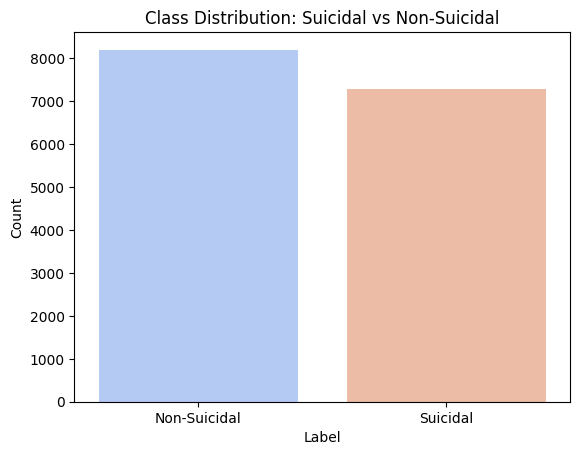

In [9]:
sns.countplot(data=df, x='label', hue='label', palette='coolwarm', legend=False)
plt.title('Class Distribution: Suicidal vs Non-Suicidal')
plt.xlabel('Label')
plt.ylabel('Count')

# Dataset Summary
Total posts: 15746 (7275 Suicidal, 8201 Non-Suicidal) <br/> <br/>
Class split: 47.01% vs 52.99% <br/><br/>

**The dataset is reasonably balanced, no class imbalance corrections are needed and t-test to be done are not skewed by label distribution.**


---

# Normalization of Counts

The feature counts where deliberately not normalized as normalizing on the entire dataset may cause data leakage. This should be done after the train and test splits are obtained. But, for the purposes of exploration, we will normalize the data temporarily.

In [10]:
df['word_count'] = df['text'].str.split().str.len()
print(df.groupby('label')['word_count'].mean())

label
Non-Suicidal    124.985855
Suicidal        163.210034
Name: word_count, dtype: float64


Since suicidal posts have on average, 38 more words per posts, raw counts are confounded by length, and without normalization, the features would overstate differences. we normalize the counts

In [11]:
df.columns

Index(['title', 'post', 'label', 'has_post', 'text', 'text_cleaned',
       'sub_metal_health_count', 'sub_dark_count', 'sub_support_count',
       'sub_total_count', 'first_person_singular', 'first_person_plural',
       'absolutist_count', 'negative_emotion', 'death_related', 'past_tense',
       'exclamation_count', 'question_count', 'upper_word_count',
       'upper_word_ratio', 'emoticon_positive', 'emoticon_negative',
       'emoticon_crying', 'emoticon_neutral', 'emoticon_heart',
       'emoticon_broken_heart', 'emoji_negative', 'emoji_positive',
       'emoji_crisis', 'emoji_implicit_distress', 'word_count'],
      dtype='str')

In [12]:
count_features = list(df.select_dtypes("int").loc[:, "first_person_singular":].columns)

count_features.remove("word_count")

for feature in count_features:
    df[f'{feature}_ratio'] = df[feature] / df['word_count']
    
rate_features = [f'{f}_ratio' for f in count_features]
print(df.groupby('label')[rate_features].mean())

              first_person_singular_ratio  first_person_plural_ratio  \
label                                                                  
Non-Suicidal                     0.102855                   0.006606   
Suicidal                         0.131494                   0.003228   

              absolutist_count_ratio  negative_emotion_ratio  \
label                                                          
Non-Suicidal                0.013578                0.001917   
Suicidal                    0.019514                0.006785   

              death_related_ratio  past_tense_ratio  exclamation_count_ratio  \
label                                                                          
Non-Suicidal             0.001405          0.019771                 0.016475   
Suicidal                 0.015611          0.011250                 0.003779   

              question_count_ratio  upper_word_count_ratio  \
label                                                        
Non-Suici

In [13]:
# display distribution

# EDA Questions
In the initial preview earlier, we saw that aside from the noticeable display of negative emotion in suicidal posts, non-suicidal posts may still exhibit this. Which leads us to the assumption that the presence of negative emotions making a text suicidal might not be as straightforward (and vice versa). This suggests that context and specific linguistic markers are also worth noting, and should not solely rely on sentiment. With this in mind, we explore patterns within the posts to determine what distinguishes posts from general distress (non-suicidal negative sentiment) to actual suicidal ideation.

## Main Question

## Main Research Question

#### **How do linguistic and emotional patterns differ between suicidal and non-suicidal posts, and which features are most discriminative?**

## Subquestions
We also formulate a few subquestions to supplement this main question.
1) Which linguistic features show the strongest differences between classes?
2) Do suicidal posts exhibit distinct combinations of features?
3) What characteristics do posts that express distress without suicidality, and posts with subtle suicidal ideation have?



---

## EDA Question 1: Which linguistic features show the strongest differences between classes?
<introduction>

To know which features distinguishes the two classes, we first get the statistical differences of their mean.

In [14]:
suicidal_rates = df[df["label"] == "Suicidal"].loc[:, rate_features]
suicidal_rates

,first_person_singular_ratio,first_person_plural_ratio,absolutist_count_ratio,negative_emotion_ratio,death_related_ratio,past_tense_ratio,exclamation_count_ratio,question_count_ratio,upper_word_count_ratio,emoticon_positive_ratio,emoticon_negative_ratio,emoticon_crying_ratio,emoticon_neutral_ratio,emoticon_heart_ratio,emoticon_broken_heart_ratio,emoji_negative_ratio,emoji_positive_ratio,emoji_crisis_ratio,emoji_implicit_distress_ratio
8201,0.055556,0.006173,0.018519,0.000000,0.006173,0.024691,0.000000,0.000000,0.006173,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8202,0.141538,0.003077,0.021538,0.003077,0.006154,0.018462,0.003077,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8203,0.135965,0.000000,0.043860,0.008772,0.000000,0.017544,0.000000,0.000000,0.004386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8204,0.152778,0.000000,0.020833,0.011574,0.006944,0.016204,0.013889,0.004630,0.004630,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8205,0.097826,0.003623,0.014493,0.000000,0.003623,0.032609,0.003623,0.003623,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15471,0.178571,0.000000,0.035714,0.035714,0.035714,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15472,0.153226,0.000000,0.056452,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15473,0.181818,0.000000,0.008264,0.016529,0.041322,0.016529,0.000000,0.000000,0.140496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15474,0.148438,0.000000,0.027344,0.011719,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
non_suicidal_rates = df[df["label"] == "Non-Suicidal"].loc[:, rate_features]
non_suicidal_rates

,first_person_singular_ratio,first_person_plural_ratio,absolutist_count_ratio,negative_emotion_ratio,death_related_ratio,past_tense_ratio,exclamation_count_ratio,question_count_ratio,upper_word_count_ratio,emoticon_positive_ratio,emoticon_negative_ratio,emoticon_crying_ratio,emoticon_neutral_ratio,emoticon_heart_ratio,emoticon_broken_heart_ratio,emoji_negative_ratio,emoji_positive_ratio,emoji_crisis_ratio,emoji_implicit_distress_ratio
0,0.117391,0.008696,0.000000,0.0,0.0,0.013043,0.004348,0.004348,0.017391,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.074257,0.014851,0.000000,0.0,0.0,0.024752,0.000000,0.004950,0.004950,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.050000,0.025000,0.025000,0.0,0.0,0.000000,0.000000,0.000000,0.050000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.110220,0.008016,0.018036,0.0,0.0,0.004008,0.000000,0.000000,0.000000,0.002004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.081522,0.016304,0.010870,0.0,0.0,0.021739,0.000000,0.005435,0.005435,0.005435,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8196,0.120690,0.017241,0.000000,0.0,0.0,0.034483,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8197,0.074074,0.024691,0.000000,0.0,0.0,0.049383,0.000000,0.000000,0.012346,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8198,0.047945,0.006849,0.013699,0.0,0.0,0.027397,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8199,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.222222,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Why we use a t-test here
We use a **Welch’s independent-samples t-test** to verify whether the difference in the means of the features between **Suicidal** and **Non-Suicidal** posts is statistically meaningful, not just due to random variation.

### How it works
- It compares the two group means relative to how spread out the scores are within each group.
- **Null hypothesis ($H_0$):** both groups have the same true mean for the features.
- **Alternative hypothesis ($H_1$):** the true means are different.
- It returns a **t-statistic** (size of difference in standardized units) and a **p-value** (how likely that difference is if $H_0$ were true).

### Decision rule
If `p < 0.05`, we reject $H_0$ and conclude there is a significant difference between groups.

In [16]:
def compare_feature(feature_name):
    """Compare single feature between classes."""
    suicidal_vals = df[df['label'] == 'Suicidal'][feature_name]
    non_suicidal_vals = df[df['label'] == 'Non-Suicidal'][feature_name]
    
    # T-test
    t_stat, p_value = stats.ttest_ind(suicidal_vals, non_suicidal_vals, equal_var=False)
    
    # Means
    mean_s = suicidal_vals.mean()
    mean_ns = non_suicidal_vals.mean()
    
    # Cohen's d
    pooled_std = np.sqrt((suicidal_vals.std()**2 + non_suicidal_vals.std()**2) / 2)
    cohens_d = (mean_s - mean_ns) / pooled_std
    
    return pd.Series({
        'Non-Suicidal Mean': mean_ns,
        'Suicidal Mean': mean_s,
        'Difference': mean_s - mean_ns,
        't-statistic': t_stat,
        'p-value': p_value,
        "Cohen's d": cohens_d
    })

# Apply to all features at once
stats_df = pd.DataFrame({
    feature: compare_feature(feature) 
    for feature in rate_features
}).T

stats_df['Significant'] = stats_df['p-value'] < 0.05

stats_df

,Non-Suicidal Mean,Suicidal Mean,Difference,t-statistic,p-value,Cohen's d,Significant
first_person_singular_ratio,0.102855,1.314943e-01,2.863962e-02,34.520052,3.277174e-251,0.557558,True
first_person_plural_ratio,0.006606,3.228059e-03,-3.378037e-03,-17.320994,1.458160e-66,-0.276423,True
absolutist_count_ratio,0.013578,1.951425e-02,5.935912e-03,17.840183,2.326854e-70,0.289970,True
negative_emotion_ratio,0.001917,6.785179e-03,4.867953e-03,25.466937,7.492841e-139,0.417409,True
death_related_ratio,0.001405,1.561062e-02,1.420560e-02,45.906770,0.000000e+00,0.758798,True
past_tense_ratio,0.019771,1.124961e-02,-8.520991e-03,-28.867977,2.499907e-178,-0.460394,True
exclamation_count_ratio,0.016475,3.778594e-03,-1.269630e-02,-6.431813,1.322840e-10,-0.105808,True
question_count_ratio,0.005038,6.151296e-03,1.112808e-03,3.657970,2.553658e-04,0.059775,True
upper_word_count_ratio,0.009066,8.690774e-03,-3.748366e-04,-0.413075,6.795581e-01,-0.006715,False
emoticon_positive_ratio,0.001168,5.867890e-05,-1.109797e-03,-13.832428,4.613569e-43,-0.216399,True


In [17]:
significant_features = stats_df[stats_df["Significant"] & ((stats_df["Cohen's d"] > 0.5) | (stats_df["Cohen's d"] < -0.5))].index # Significant and has moderate to great effect size both ways.

significant_features

Index(['first_person_singular_ratio', 'death_related_ratio'], dtype='str')

In [18]:
stats_df.loc[significant_features, ["p-value", "Cohen's d"]]

,p-value,Cohen's d
first_person_singular_ratio,3.277174e-251,0.557558
death_related_ratio,0.000000e+00,0.758798


Given these, we can see that the use of first person singular pronouns and death related words is significantly different between the classes and are discriminatory features. We notice that suicidal posts have more of it. We can interpret this as more suicidal posts tend to have a reflecting sentiment (narrating their struggles and seeking for advice) with apparent mentions of mortality or self harm.

In [19]:
significant_subset = df.loc[:, [*significant_features, "label"]]

C:\Users\Ezra\AppData\Local\Temp\ipykernel_23228\3578738496.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=significant_subset, x="label", y=significant_features[i], palette='coolwarm', ax=ax[i])
C:\Users\Ezra\AppData\Local\Temp\ipykernel_23228\3578738496.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=significant_subset, x="label", y=significant_features[i], palette='coolwarm', ax=ax[i])


Text(0.5, 0.98, 'Comparison of Significant Features by Label')

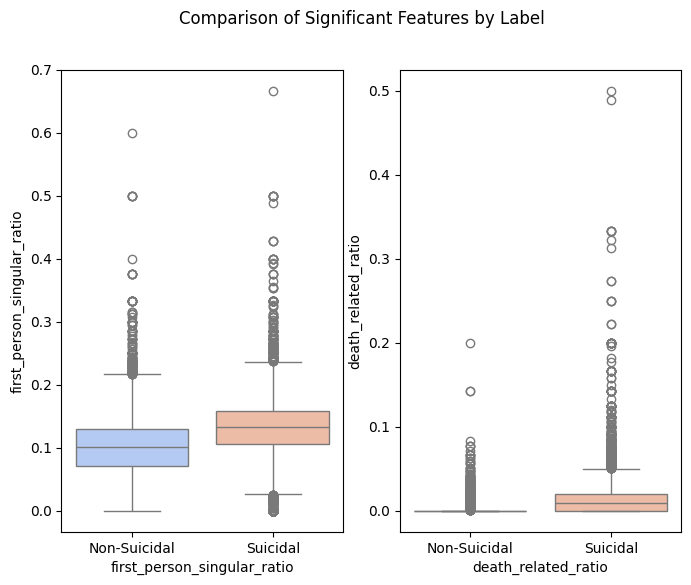

In [20]:
fig, ax = plt.subplots(1, len(significant_features), figsize=[8, 6])
ax.flatten()

for i in range(len(significant_features)):
    sns.boxplot(data=significant_subset, x="label", y=significant_features[i], palette='coolwarm', ax=ax[i])
    ax[i].set_xlabel(significant_features[i])

fig.suptitle('Comparison of Significant Features by Label')


This further proves the difference of the significant features in both classes. Keeping note of this can help us understand the behavior of our models later on.

---

## EDA Question 2: Do suicidal posts exhibit distinct combinations of features?

<introduction>

In this question, we aim to see the relationships of the features within each classes. We only use the ratio columns for the linguistic features.

In [86]:
num_features = df.select_dtypes("number").loc[:, "sub_metal_health_count":"emoji_implicit_distress"] # excludes has_post (boolean)
num_features = pd.concat([num_features, df["label"]], axis=1)



In [92]:
ratio_correlations_suicidal = num_features[num_features["label"] == "Suicidal"].drop(["label"], axis=1).corr()
ratio_correlations_non_suicidal = num_features[num_features["label"] == "Non-Suicidal"].drop(["label"], axis=1).corr()



We ignore the NaN as they are caused by the sub_dark_count, instances apparently did not mention any of the subreddits listed there.

Text(0.5, 1.0, 'Correlation Matrix of Count/Ratio Features')

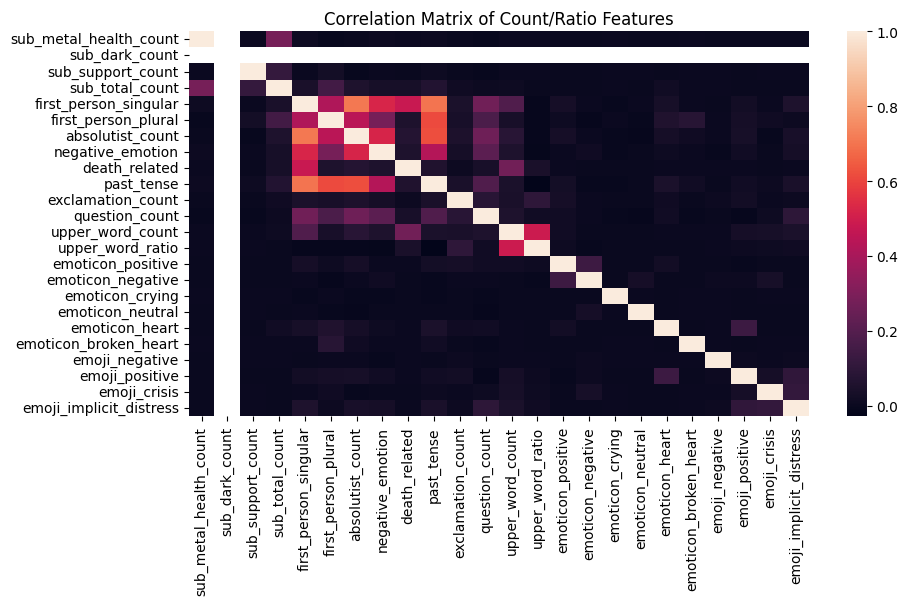

In [93]:
plt.figure(figsize=[10, 5])
sns.heatmap(ratio_correlations_suicidal)
plt.title("Correlation Matrix of Count/Ratio Features")

Text(0.5, 1.0, 'Correlation Matrix of Count/Ratio Features')

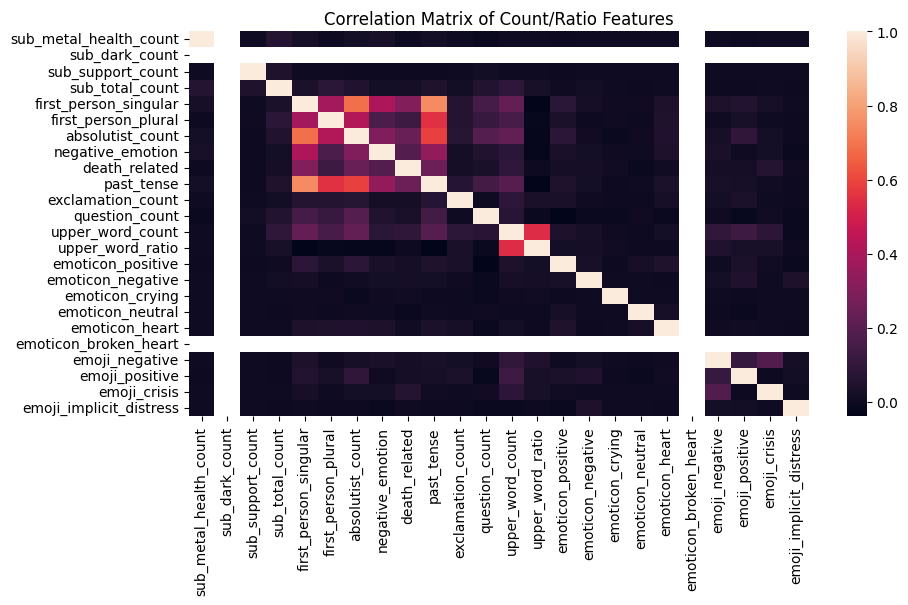

In [94]:
plt.figure(figsize=[10, 5])
sns.heatmap(ratio_correlations_non_suicidal)
plt.title("Correlation Matrix of Count/Ratio Features")

In [66]:
def get_good_correlations(correlation_mat):
    good_ratio_correlations =  correlation_mat.map(lambda x : (x > 0.3 or x < -0.3)) #  0.3 < x < -0.3
    good_ratio_correlations_indices = list(zip(*np.where(good_ratio_correlations)))

    indices = correlation_mat.index
    good_ratio_correlations_vals = []
    index_buffer = [] # list of indices so reverses are not included

    for index in good_ratio_correlations_indices:
        i, j = index

        if i != j:
            row, col = indices[i], indices[j]

            if (col, row) not in index_buffer:
                good_ratio_correlations_vals.append({"key": (row, col), "val": correlation_mat.loc[row, col]})
                index_buffer.append((row, col))

    good_ratio_correlations_vals.sort(key=lambda x: x["val"], reverse=True)

    good_ratio_correlations_vals = pd.DataFrame(good_ratio_correlations_vals)

    return good_ratio_correlations_vals


In [95]:
good_ratio_correlations_suicidal = get_good_correlations(ratio_correlations_suicidal)
good_ratio_correlations_suicidal

,key,val
0,"(first_person_singular, absolutist_count)",0.707225
1,"(first_person_singular, past_tense)",0.699225
2,"(absolutist_count, past_tense)",0.620555
3,"(first_person_plural, past_tense)",0.611319
4,"(first_person_singular, negative_emotion)",0.524926
5,"(absolutist_count, negative_emotion)",0.518695
6,"(upper_word_count, upper_word_ratio)",0.486132
7,"(first_person_singular, death_related)",0.479908
8,"(first_person_plural, absolutist_count)",0.445055
9,"(negative_emotion, past_tense)",0.426242


In [98]:
good_ratio_correlations_non_suicidal = get_good_correlations(ratio_correlations_non_suicidal)
good_ratio_correlations_non_suicidal

,key,val
0,"(first_person_singular, past_tense)",0.751211
1,"(first_person_singular, absolutist_count)",0.686360
2,"(absolutist_count, past_tense)",0.583271
3,"(first_person_plural, past_tense)",0.549580
4,"(upper_word_count, upper_word_ratio)",0.540326
5,"(first_person_plural, absolutist_count)",0.415805
6,"(first_person_singular, negative_emotion)",0.405126
7,"(first_person_singular, first_person_plural)",0.382219
8,"(negative_emotion, past_tense)",0.339296
9,"(first_person_singular, death_related)",0.303966


To get a closer look, we plot the scatterplot of the feature pair with the greatest correlation of both classes.

Text(0.5, 1.0, '[SUICIDAL] Scatterplot of first_person_singular and absolutist_count')

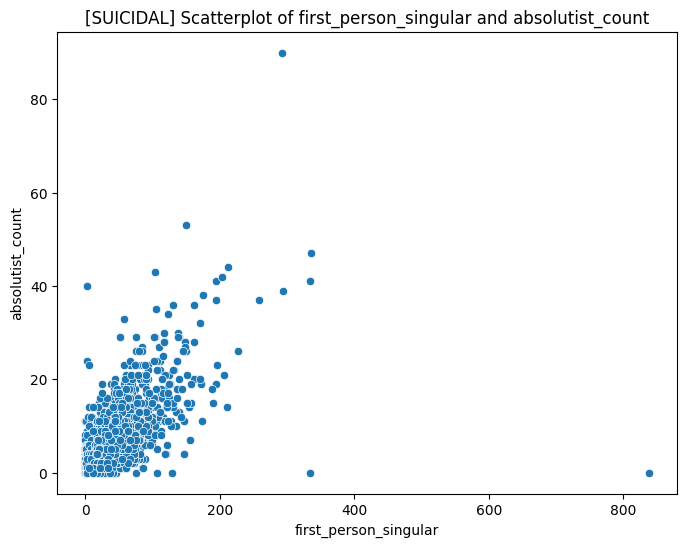

In [101]:
plt.figure(figsize=[8, 6])
sns.scatterplot(data=df, x="first_person_singular", y="absolutist_count")
plt.title("[SUICIDAL] Scatterplot of first_person_singular and absolutist_count")


Text(0.5, 1.0, '[NON-SUICIDAL] Scatterplot of first_person_singular and past_tense')

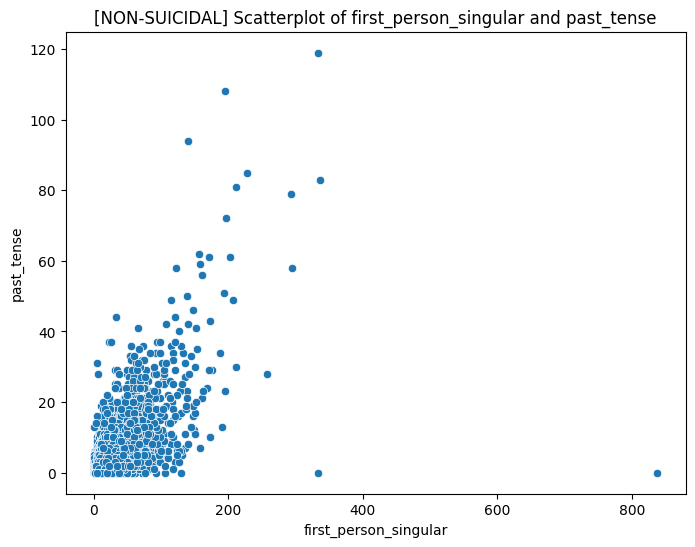

In [104]:
plt.figure(figsize=[8, 6])
sns.scatterplot(data=df, x="first_person_singular", y="past_tense")
plt.title("[NON-SUICIDAL] Scatterplot of first_person_singular and past_tense")

This tells us that in suicidal posts absolutist words appear commonly with first person singular words. This is often seen in posts narrating life experiences and it is highly reasonable that they appear with absolutist words often in suicidal posts.

---

## EDA Question 3: What characteristics do posts that express distress without suicidality, and posts with subtle suicidal ideation have?

<introduction>

In here, we tackle misleading or ambiguous posts. This means non-suicidal posts with high negative word counts or suicidal posts with low negative word counts.

In [118]:
ratio_columns = list(df.loc[:, "first_person_singular_ratio":].columns)



In [119]:
q75_by_class = df.groupby("label")[ratio_columns].quantile(0.75)
q75_by_class

,first_person_singular_ratio,first_person_plural_ratio,absolutist_count_ratio,negative_emotion_ratio,death_related_ratio,past_tense_ratio,exclamation_count_ratio,question_count_ratio,upper_word_count_ratio,emoticon_positive_ratio,emoticon_negative_ratio,emoticon_crying_ratio,emoticon_neutral_ratio,emoticon_heart_ratio,emoticon_broken_heart_ratio,emoji_negative_ratio,emoji_positive_ratio,emoji_crisis_ratio,emoji_implicit_distress_ratio
label,,,,,,,,,,,,,,,,,,,
Non-Suicidal,0.129630,0.008403,0.021008,0.000000,0.00,0.030769,0.014706,0.003236,0.005882,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Suicidal,0.157895,0.002204,0.027322,0.009009,0.02,0.018182,0.000000,0.004237,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [120]:
q25_by_class = df.groupby("label")[ratio_columns].quantile(0.25)
q25_by_class

,first_person_singular_ratio,first_person_plural_ratio,absolutist_count_ratio,negative_emotion_ratio,death_related_ratio,past_tense_ratio,exclamation_count_ratio,question_count_ratio,upper_word_count_ratio,emoticon_positive_ratio,emoticon_negative_ratio,emoticon_crying_ratio,emoticon_neutral_ratio,emoticon_heart_ratio,emoticon_broken_heart_ratio,emoji_negative_ratio,emoji_positive_ratio,emoji_crisis_ratio,emoji_implicit_distress_ratio
label,,,,,,,,,,,,,,,,,,,
Non-Suicidal,0.071429,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Suicidal,0.104961,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [145]:
# Ambiguous non-suicidal: high negative emotion but no death-related terms
pd.set_option('display.max_colwidth', None)
ns_q75_neg = q75_by_class.loc['Non-Suicidal', 'negative_emotion_ratio']

print("75th Percentile: ", ns_q75_neg)


ambiguous_nonsuicidal = df[
    (df['label'] == 'Non-Suicidal') &
    (df['negative_emotion_ratio'] >= ns_q75_neg) &
    (df['death_related_ratio'] == 0)
]

ambiguous_nonsuicidal["text_cleaned"].sample(10, random_state=random_seed)

75th Percentile:  0.0


363                      I just got my dream job!!!!! I am so excited and I just want to share with anyone and everyone. I just got my dream job!!!! It’s something I don’t have much experience with, so I’m nervous, but so happy. Not totally sure about the start date yet, but soon. I’m going to be an organizer for my state’s public education union. Anyone with labor organizing experience, any tips? This will improve so many things in my life. Literally double my current salary. I will never again have to see a certain coworker who is one of the worst human beings I have ever met. It will be wonderful experience for my future career goals. I’ll get to use what I’m learning in grad school. I will have a little more flexibility in my schedule. More time off. I’ll actually be treated like a responsible professional adult. I’ll be a part of an effective union!
445                                                                                                                                  

In [146]:
# Subtle suicidal: suicidal but low death-related
pd.set_option('display.max_colwidth', None)
s_q25_death = df[df['label'] == 'Suicidal']['death_related_ratio'].quantile(0.25)

print("25th Percentile: ", s_q25_death)

subtle_suicidal = df[
    (df['label'] == 'Suicidal') &
    (df['death_related_ratio'] <= s_q25_death)
]

subtle_suicidal["text_cleaned"].sample(10, random_state=random_seed)

25th Percentile:  0.0


13087                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

To be able to analyze the emotional tone of the data, we can look at the distribution of the `negative_emotion` feature counts for "Suicidal" and "Non-Suicidal" labels.
This helps us understand how prevalent negative emotional language is in each group and whether one label consistently shows higher intensity.
We can begin by comparing group means, then visualize spread and outliers using a boxplot, and finally check statistical significance with an independent-samples test.

In [22]:
# Calculate the mean negative emotion for each label
print(df.groupby('label')['negative_emotion_rate'].mean())

KeyError: 'Column not found: negative_emotion_rate'

- Non-Suicidal mean `negative_emotion_rate` = 0.001917
- Suicidal mean `negative_emotion_rate` = 0.006785

This means suicidal posts have on average 3.5× the rate of negative emotional 
language per word compared to non-suicidal posts. This indicates that negative 
emotional language is associated with the suicidal label even after controlling 
for post length.

To better visualize it, we create a boxplot showcasing the comparison across the 2 labels

C:\Users\Ezra\AppData\Local\Temp\ipykernel_23752\353492069.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='negative_emotion_rate', palette='coolwarm')


Text(0, 0.5, 'Negative Emotion Count')

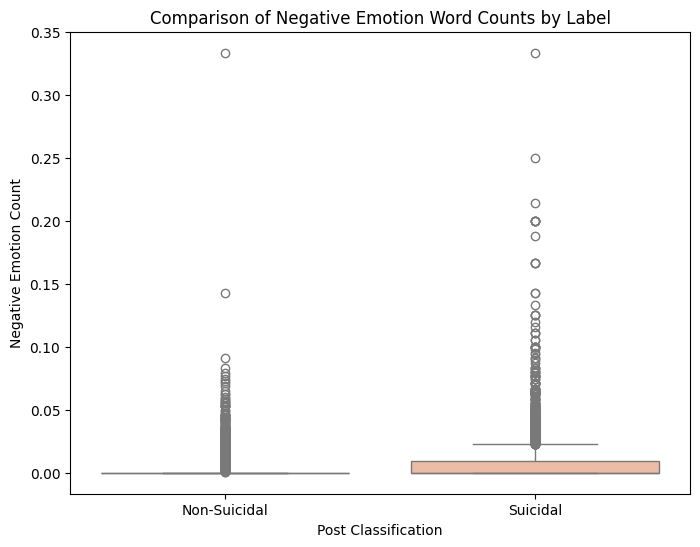

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='negative_emotion_rate', palette='coolwarm')

plt.title('Comparison of Negative Emotion Word Counts by Label')
plt.xlabel('Post Classification')
plt.ylabel('Negative Emotion Count')

From the boxplot, the **Suicidal** group is shifted upward compared with the **Non-Suicidal** group, meaning its median and most values of `negative_emotion` are higher.

The box (IQR) for Suicidal posts is also at higher values, which shows that even the middle 50% of that group tends to use more negative-emotion language.

There may still be some overlap between groups, but the clear upward shift supports the earlier mean comparison and suggests a strong association between higher `negative_emotion` and the suicidal label.

### Why we use a t-test here
We use a **Welch’s independent-samples t-test** to verify whether the difference in average `negative_emotion` between **Suicidal** and **Non-Suicidal** posts is statistically meaningful, not just due to random variation.

### How it works
- It compares the two group means relative to how spread out the scores are within each group.
- **Null hypothesis ($H_0$):** both groups have the same true mean `negative_emotion`.
- **Alternative hypothesis ($H_1$):** the true means are different.
- It returns a **t-statistic** (size of difference in standardized units) and a **p-value** (how likely that difference is if $H_0$ were true).

### Decision rule
If `p < 0.05`, we reject $H_0$ and conclude there is a significant difference between groups.

In [ ]:
suicidal_emo = df[df['label'] == 'Suicidal']['negative_emotion_rate']
non_suicidal_emo = df[df['label'] == 'Non-Suicidal']['negative_emotion_rate']

t_stat, p_value = stats.ttest_ind(suicidal_emo, non_suicidal_emo, equal_var=False)

print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 25.4669
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The p-value is effectively 0.0000 (< 0.05), so we reject $H_0$ and conclude 
there is a statistically significant difference in mean `negative_emotion_rate` 
between the two labels.

---

## EDA Question 2: Is there a statistically significant difference in first-person singular pronoun usage between Suicidal and Non-Suicidal posts?

<introduction>

In [ ]:
# Calculate the mean first_person_singular for each label
print("Mean first_person_singular by label:")
print(df.groupby('label')['first_person_singular_rate'].mean())

Mean first_person_singular by label:
label
Non-Suicidal    0.102855
Suicidal        0.131494
Name: first_person_singular_rate, dtype: float64


- Non-Suicidal mean `first_person_singular_rate` = 0.10285
- Suicidal mean `first_person_singular_rate` = 0.13149

The p-value is effectively 0.0000 (< 0.05), so we reject $H_0$ and conclude 
there is a statistically significant difference in first-person singular pronoun 
usage per word between the two labels. Suicidal posts use first-person singular 
pronouns at a 1.28× higher rate, consistent with the known psychological pattern 
of self-focused rumination in suicidal ideation.

C:\Users\Ezra\AppData\Local\Temp\ipykernel_23752\1165275194.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='first_person_singular_rate', palette='coolwarm')


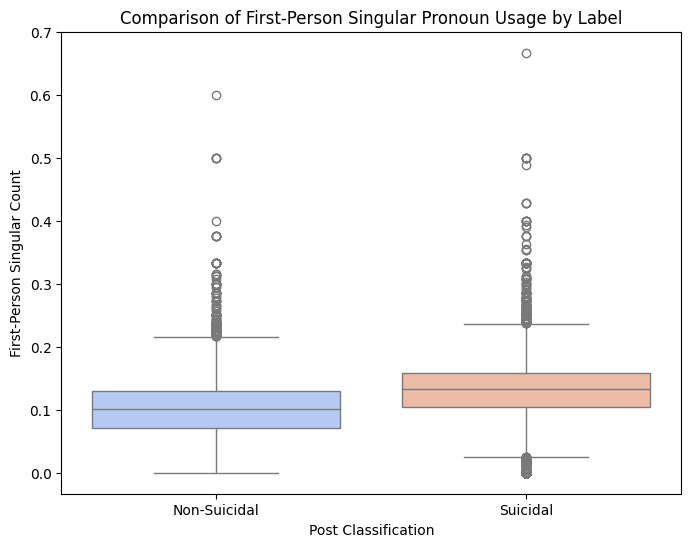

In [ ]:
# Boxplot: first_person_singular across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='first_person_singular_rate', palette='coolwarm')

plt.title('Comparison of First-Person Singular Pronoun Usage by Label')
plt.xlabel('Post Classification')
plt.ylabel('First-Person Singular Count')
plt.show()

In [ ]:
suicidal_fp = df[df['label'] == 'Suicidal']['first_person_singular_rate']
non_suicidal_fp = df[df['label'] == 'Non-Suicidal']['first_person_singular_rate']

t_stat, p_value = stats.ttest_ind(suicidal_fp, non_suicidal_fp, equal_var=False)
print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 34.5201
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The Welch's t-test showed that there is a statistically significant difference between first-person singular usage

---

## EDA Question 3: Is there a statistically significant difference in the death related word usage between the two labels?
<introduction>

To be able to analyze the another type of emotional tone of the data, we can look at the distribution of the `death_related` feature counts for "Suicidal" and "Non-Suicidal" labels.
This helps us understand how prevalent death related language is in each group and whether one label consistently shows higher intensity.
We can begin by comparing group means, then visualize spread and outliers using a boxplot, and finally check statistical significance with an independent-samples test.

In [ ]:
# Calculate the mean negative emotion for each label
print(df.groupby('label')['death_related_rate'].mean())

label
Non-Suicidal    0.001405
Suicidal        0.015611
Name: death_related_rate, dtype: float64


- Non-Suicidal mean `death_related_rate` = 0.001041
- Suicidal mean `death_related_rate` = 0.015253

Even after normalizing for post length, suicidal posts use death-related vocabulary 
at approximately 14.6× the rate of non-suicidal posts. This is the most pronounced 
difference across all features, confirming that explicit death-related language is 
the strongest differentiator between the two labels.

C:\Users\Ezra\AppData\Local\Temp\ipykernel_23752\249123705.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='death_related_rate', palette='coolwarm')


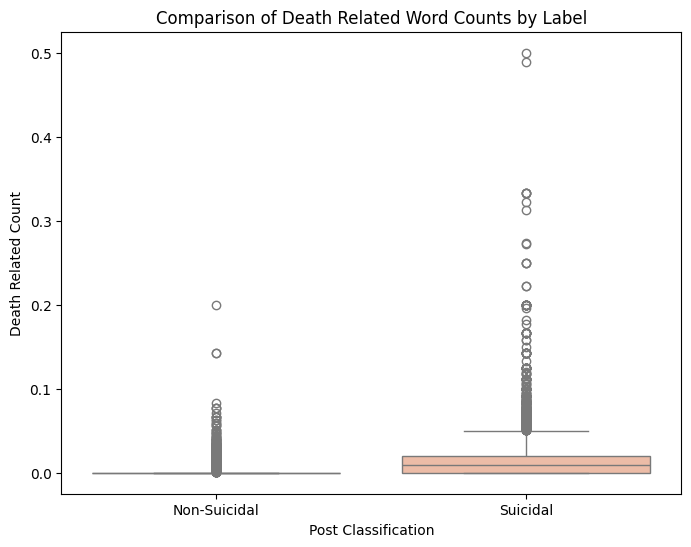

In [ ]:

# Create a boxplot to compare negative_emotion across labels
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='death_related_rate', palette='coolwarm')

plt.title('Comparison of Death Related Word Counts by Label')
plt.xlabel('Post Classification')
plt.ylabel('Death Related Count')
plt.show()

From the boxplot, the **Suicidal** group is dramatically shifted upward compared to the **Non-Suicidal** group. The median and interquartile range (IQR) for Suicidal posts sit at considerably higher `death_related` counts, while the Non-Suicidal box is compressed near zero — indicating that most non-suicidal posts contain little to no death-related language at all.

The Suicidal group also shows a longer upper whisker and more high-value outliers, reflecting that a notable subset of suicidal posts use death-related vocabulary very heavily.

This near-zero baseline for Non-Suicidal posts combined with the elevated range for Suicidal posts reinforces that `death_related` is a strong and clear separator between the two labels — more so than `negative_emotion`, where there was more overlap between groups.


### Decision rule for T-test statistic
If `p < 0.05`, we reject $H_0$ and conclude there is a significant difference between groups.

In [ ]:
suicidal_dr = df[df['label'] == 'Suicidal']['death_related_rate']
non_suicidal_dr = df[df['label'] == 'Non-Suicidal']['death_related_rate']

t_stat, p_value = stats.ttest_ind(suicidal_dr, non_suicidal_dr, equal_var=False)

print(f"Welch's t-test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Welch's t-test statistic: 45.9068
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The p-value is effectively 0.0000 (< 0.05), so we **reject $H_0$** and conclude there is a statistically significant difference in mean `death_related` word usage between Suicidal and Non-Suicidal posts.

The large t-statistic magnitude further confirms that the separation between groups is not a fluke — the difference is far greater than what would be expected from random variation alone.

Combined with the 14.6× difference in group means and the clearly separated boxplot distributions, this result strongly supports the conclusion that **death-related language is a highly discriminative feature** for identifying suicidal posts.

---

## EDA Question 4: Is there a statistically significant difference in the usage of 'absolutist' language and intense punctuation (exclamations) between Suicidal and Non-Suicidal labels?
<introduction>

In [ ]:
print("Mean absolutist_count by label:")
print(df.groupby('label')['absolutist_count_rate'].mean())

print("\nMean exclamation_count by label:")
print(df.groupby('label')['exclamation_count_rate'].mean())

Mean absolutist_count by label:
label
Non-Suicidal    0.013578
Suicidal        0.019514
Name: absolutist_count_rate, dtype: float64

Mean exclamation_count by label:
label
Non-Suicidal    0.016475
Suicidal        0.003779
Name: exclamation_count_rate, dtype: float64


- Non-Suicidal mean `absolutist_count_rate` = 0.013579, Suicidal mean = 0.019513 → **~1.44× higher** in Suicidal posts
- Non-Suicidal mean `exclamation_count_rate` = 0.016475, Suicidal mean = 0.003779 → **~4.4× higher** in Non-Suicidal posts

The absolutist language gap holds after normalization — suicidal cognition is 
associated with rigid, all-or-nothing thinking. The exclamation rate result 
confirms the same counterintuitive pattern: Non-Suicidal posts use exclamations 
at a far higher rate per word, reflecting casual expressiveness rather than 
emotional distress.

C:\Users\Ezra\AppData\Local\Temp\ipykernel_23752\3166334684.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='absolutist_count_rate', palette='coolwarm', ax=axes[0])
C:\Users\Ezra\AppData\Local\Temp\ipykernel_23752\3166334684.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='exclamation_count_rate', palette='coolwarm', ax=axes[1])


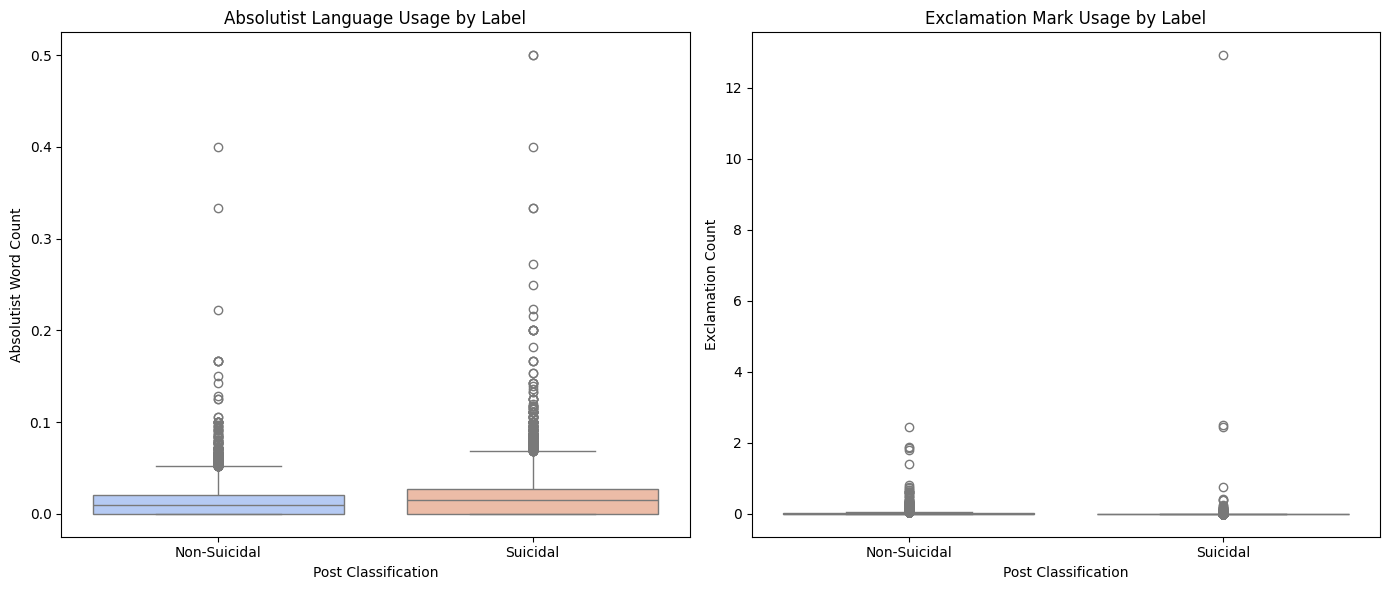

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='label', y='absolutist_count_rate', palette='coolwarm', ax=axes[0])
axes[0].set_title('Absolutist Language Usage by Label')
axes[0].set_xlabel('Post Classification')
axes[0].set_ylabel('Absolutist Word Count')

sns.boxplot(data=df, x='label', y='exclamation_count_rate', palette='coolwarm', ax=axes[1])
axes[1].set_title('Exclamation Mark Usage by Label')
axes[1].set_xlabel('Post Classification')
axes[1].set_ylabel('Exclamation Count')

plt.tight_layout()
plt.show()

For `absolutist_count`, the **Suicidal** box sits notably higher than the Non-Suicidal box, with a higher median and wider IQR — consistent with the mean difference. The spread also indicates that heavy absolutist language is common across a large portion of suicidal posts, not just outliers.

For `exclamation_count`, the pattern **reverses**: the Non-Suicidal group has a higher median and wider IQR, while the Suicidal box is compressed near zero. This indicates that suicidal posts are largely devoid of exclamations, reflecting a flat, resigned tone rather than heightened emotional expression.

In [ ]:
suicidal_abs = df[df['label'] == 'Suicidal']['absolutist_count_rate']
non_suicidal_abs = df[df['label'] == 'Non-Suicidal']['absolutist_count_rate']

t_stat, p_value = stats.ttest_ind(suicidal_abs, non_suicidal_abs, equal_var=False)

print(f"Absolutist Usage — Welch's t-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Absolutist Usage — Welch's t-statistic: 17.8402
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The p-value is effectively 0.0000 (< 0.05), so we **reject $H_0$** for `absolutist_count`. There is a statistically significant difference in absolutist language usage between Suicidal and Non-Suicidal posts.

The large positive t-statistic (17.84) confirms that Suicidal posts score substantially higher. This aligns with the cognitive distortion literature, where suicidal ideation is strongly associated with absolutist, black-and-white thinking (e.g., words like *"always"*, *"never"*, *"nothing"*, *"completely"*).

In [ ]:
suicidal_exc = df[df['label'] == 'Suicidal']['exclamation_count_rate']
non_suicidal_exc = df[df['label'] == 'Non-Suicidal']['exclamation_count_rate']

t_stat, p_value = stats.ttest_ind(suicidal_exc, non_suicidal_exc, equal_var=False)

print(f"Exclamation Usage — Welch's t-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

Exclamation Usage — Welch's t-statistic: -6.4318
P-value: 0.0000
Result: Statistically significant difference (p < 0.05)


The p-value is effectively 0.0000 (< 0.05), so we **reject $H_0$** for `exclamation_count` as well. There is a statistically significant difference. Notably, the **t-statistic is negative (−6.4318)**, meaning the Suicidal group has a *lower* mean than the Non-Suicidal group.

This reveals that exclamation marks are not an indicator of emotional distress in suicidal posts. Rather, their near-absence in suicidal content reflects a tone of **emotional flatness and resignation** — a stark contrast to the expressive, energetic punctuation style more typical of casual non-suicidal discourse.


---
## Feature Correlation Analysis
Before concluding, we check whether the five core features are 
correlated with each other, as high correlation would indicate 
redundant signals.

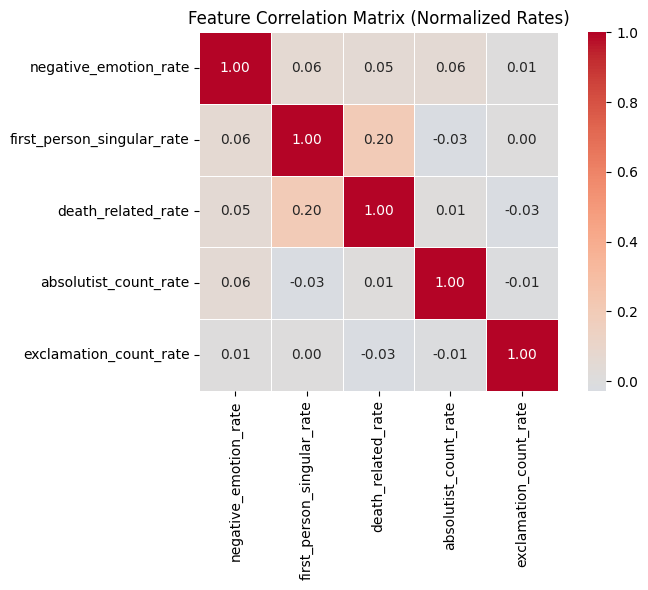

In [ ]:
corr_features = [
    'negative_emotion_rate',
    'first_person_singular_rate',
    'death_related_rate',
    'absolutist_count_rate',
    'exclamation_count_rate'
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix (Normalized Rates)')
plt.tight_layout()
plt.show()

## Feature Correlation Matrix

All five normalized features are largely independent of one another.
The highest observed correlation is between `first_person_singular_rate` 
and `death_related_rate` (r=0.20), which is negligible.

**Key takeaway:** No multicollinearity is present. Each feature captures 
a distinct linguistic dimension and contributes unique signal.


---
## Distribution Analysis (KDE Plots)
Boxplots summarize central tendency but hide distributional shape. 
KDE plots reveal the full spread, skewness, and class overlap for 
each normalized feature.

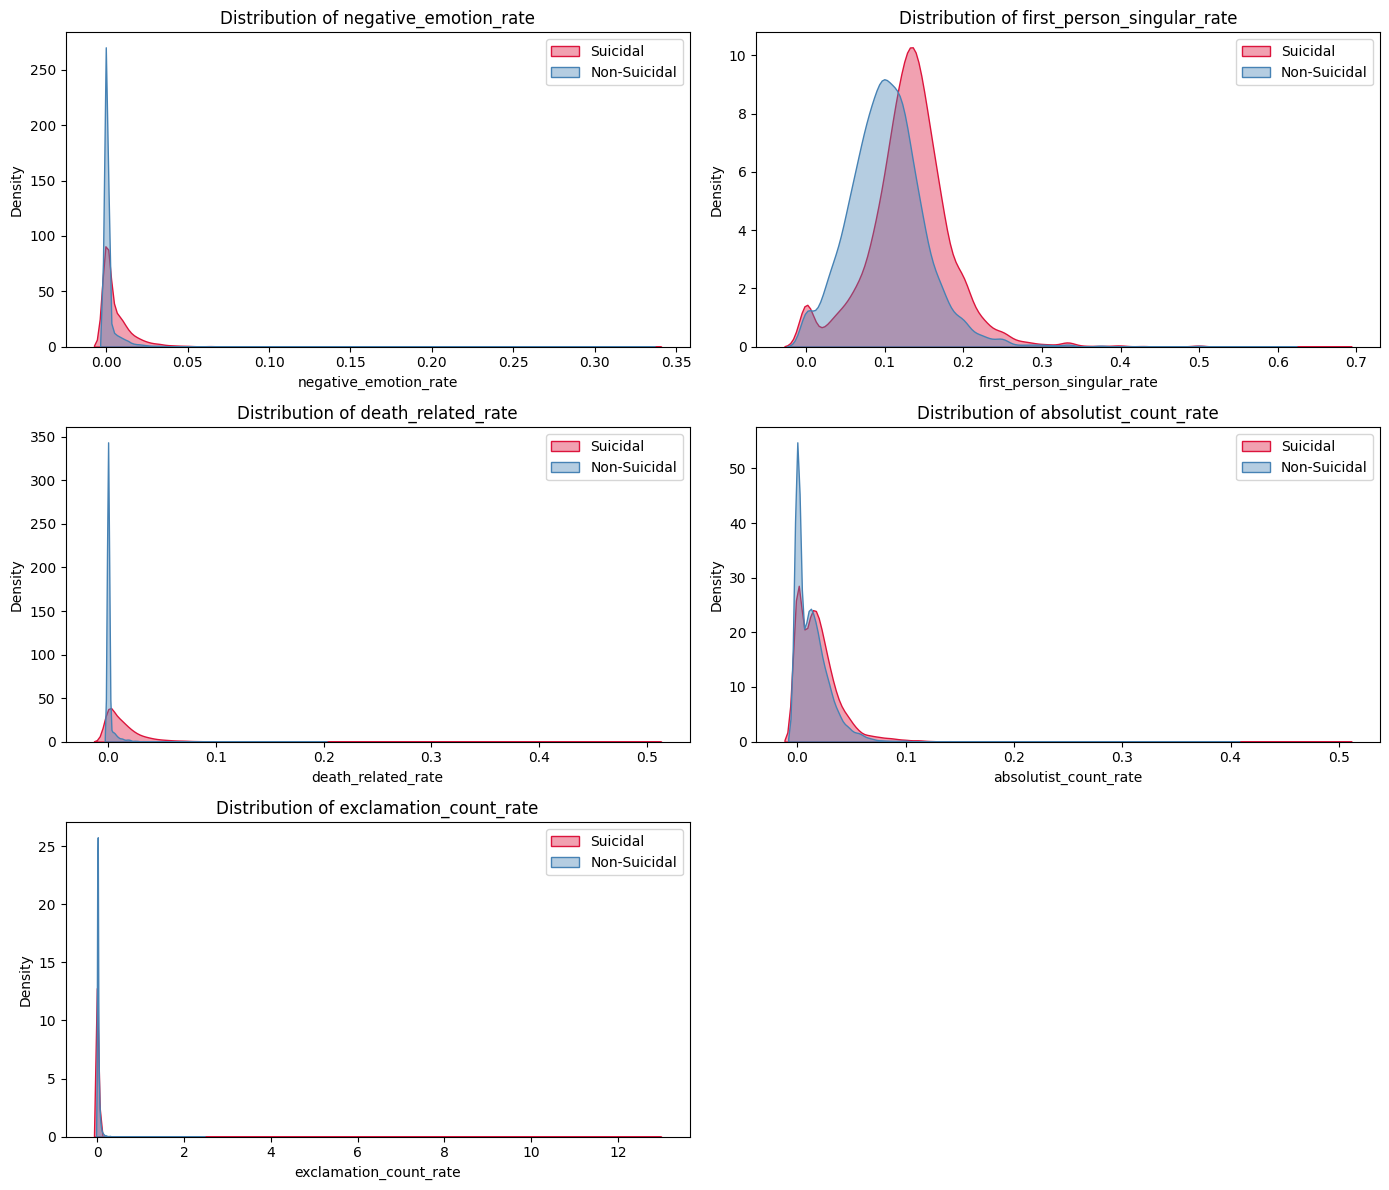

In [ ]:
rate_features = [
    'negative_emotion_rate',
    'first_person_singular_rate',
    'death_related_rate',
    'absolutist_count_rate',
    'exclamation_count_rate'
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, feature in enumerate(rate_features):
    for label, color in zip(['Suicidal', 'Non-Suicidal'], ['crimson', 'steelblue']):
        subset = df[df['label'] == label][feature]
        sns.kdeplot(subset, ax=axes[i], label=label, color=color, fill=True, alpha=0.4)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].legend()

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

Since exclamation_count_rate are spiked near zero but there are extreme outliers stretching to 13+ on the x-axis. Those outliers are destroying the plot's readability. This needs to be clipped.

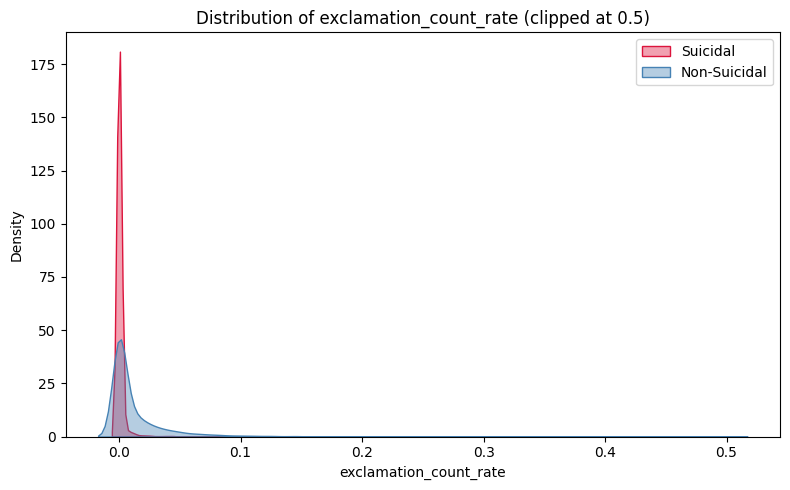

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, color in zip(['Suicidal', 'Non-Suicidal'], ['crimson', 'steelblue']):
    subset = df[df['label'] == label]['exclamation_count_rate']
    subset_clipped = subset[subset <= 0.5]
    sns.kdeplot(subset_clipped, ax=ax, label=label, color=color, fill=True, alpha=0.4)

ax.set_title('Distribution of exclamation_count_rate (clipped at 0.5)')
ax.set_xlabel('exclamation_count_rate')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

## KDE Distributions (Normalized Features)

- `first_person_singular_rate`: Clearest visual separation — Suicidal 
  distribution is shifted right with a distinct peak at a higher rate.
  
- `death_related_rate`: Non-Suicidal posts are almost entirely zero. 
  Suicidal posts show a right tail — confirming it as the most 
  discriminative feature.

- `negative_emotion_rate`: Both groups spike near zero but Suicidal 
  posts have a heavier right tail, indicating a meaningful subset of 
  posts with high emotional language density.

- `absolutist_count_rate`: Heavy overlap between groups. Visually 
  confirms the weak Cohen's d (0.29) — this feature provides limited 
  separability on its own.

- `exclamation_count_rate`: Non-Suicidal posts have a slightly higher 
  rate with extreme outliers present. After clipping, the near-zero 
  concentration of Suicidal posts becomes clearer — confirming the 
  flat, resigned tone finding.

---

## Conclusion: Emotional Vocabulary vs. Grammatical Structure in Suicidal Posts

The central question of this EDA was:

> **Does the 'Suicidal' label manifest more through emotional vocabulary or through 
> specific grammatical structures (like self-focus and punctuation usage)?**

Across all four EDA questions, every feature showed a statistically significant 
difference between Suicidal and Non-Suicidal posts (all p < 0.05). The findings 
are summarized below:

| Feature | Suicidal Rate | Non-Suicidal Rate | Ratio | t-statistic | Cohen's d | Significant? |
|---|---|---|---|---|---|---|
| `negative_emotion_rate` | 0.006785 | 0.001917 | 3.5× higher | +25.47 | 0.42 | Yes |
| `first_person_singular_rate` | 0.13149 | 0.10285 | 1.28× higher | +34.53 | 0.56 | Yes |
| `death_related_rate` | 0.015253 | 0.001041 | 14.6× higher | +46.23 | 0.76 | Yes |
| `absolutist_count_rate` | 0.019513 | 0.013579 | 1.44× higher | +17.84 | 0.29 | Yes |
| `exclamation_count_rate` | 0.003779 | 0.016475 | 4.4× **lower** | −6.43 | -0.11 | Yes |

### Answer

The evidence points to **both** dimensions playing a role, but **emotional vocabulary 
is the stronger and more discriminative signal**:

- `death_related` showed the largest raw separation (14.5× difference), making it 
  the single most discriminative feature in this analysis. A post containing explicit 
  death-related language is far more likely to be Suicidal than Non-Suicidal.
- `negative_emotion` also showed a strong 3.9× gap, confirming that suicidal posts 
  are saturated with negative emotional language broadly, not just death-specific terms.

Grammatical structure also plays a meaningful role, but in a more nuanced way:

- `first_person_singular` is elevated in Suicidal posts (1.7×), consistent with the 
  known psychological pattern of self-focused rumination in suicidal ideation.
- `absolutist_count` is elevated (1.7×), reflecting the rigid, all-or-nothing thinking 
  commonly associated with suicidal cognition.
- `exclamation_count` is markedly **lower** in Suicidal posts (7.1×), revealing that 
  suicidal language is tonally flat and resigned — not emotionally explosive.

### Key Takeaway

Suicidal posts are best characterized by a combination of **what words are used** 
(death-related and negative emotional vocabulary) and **how language is structured** 
(self-focused, absolutist, and devoid of expressive punctuation). If forced to choose 
one dimension, emotional vocabulary — particularly death-related language — is the 
stronger differentiator. However, the grammatical markers (especially the *absence* 
of exclamation marks) add meaningful signal that emotional vocabulary alone does not 
capture.